In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
baseline = pd.read_csv('../baseline_predictions/BBBP_test_predictions.csv')
threshold = 0.5
baseline['Predicted_Label'] = baseline['GNN_Prediction'].apply(lambda x: 1 if x >= threshold else 0)

qwen_small_predictions = pd.read_csv('./predictions/qwen2_bbbp_lora_no_few_shot_predictions.csv')
qwen_small_2_shots_predictions = pd.read_csv('./predictions/qwen2_bbbp_lora_2_shots__predictions.csv')
qwen_small_4_shots_predictions = pd.read_csv('./predictions/qwen2_bbbp_lora_4_shots__predictions.csv')
qwen_small_6_shots_predictions = pd.read_csv('./predictions/qwen2_bbbp_lora_6_shots__predictions.csv')
qwen_small_8_shots_predictions = pd.read_csv('./predictions/qwen2_bbbp_lora_8_shots__predictions.csv')

qwen_large_predictions = pd.read_csv('./predictions/qwen2_7B_bbbp_lora_predictions.csv')
qwen_large_2_shots_predictions = pd.read_csv('./predictions/qwen2_7B_bbbp_lora_2_shots_predictions.csv')
qwen_large_4_shots_predictions = pd.read_csv('./predictions/qwen2_7B_bbbp_lora_4_shots_predictions.csv')
qwen_large_6_shots_predictions = pd.read_csv('./predictions/qwen2_7B_bbbp_lora_6_shots_predictions.csv')
qwen_large_8_shots_predictions = pd.read_csv('./predictions/qwen2_7B_bbbp_lora_8_shots_predictions.csv')


In [4]:
# Compute classification metrics
def compute_metrics(df, label_col='True_Label', pred_col='Predicted_Label'):
    true = df[label_col]
    pred = df[pred_col]
    tp = ((true == 1) & (pred == 1)).sum()
    tn = ((true == 0) & (pred == 0)).sum()
    fp = ((true == 0) & (pred == 1)).sum()
    fn = ((true == 1) & (pred == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return {
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn
    }



#### Qwen2-1.5B-Instruct

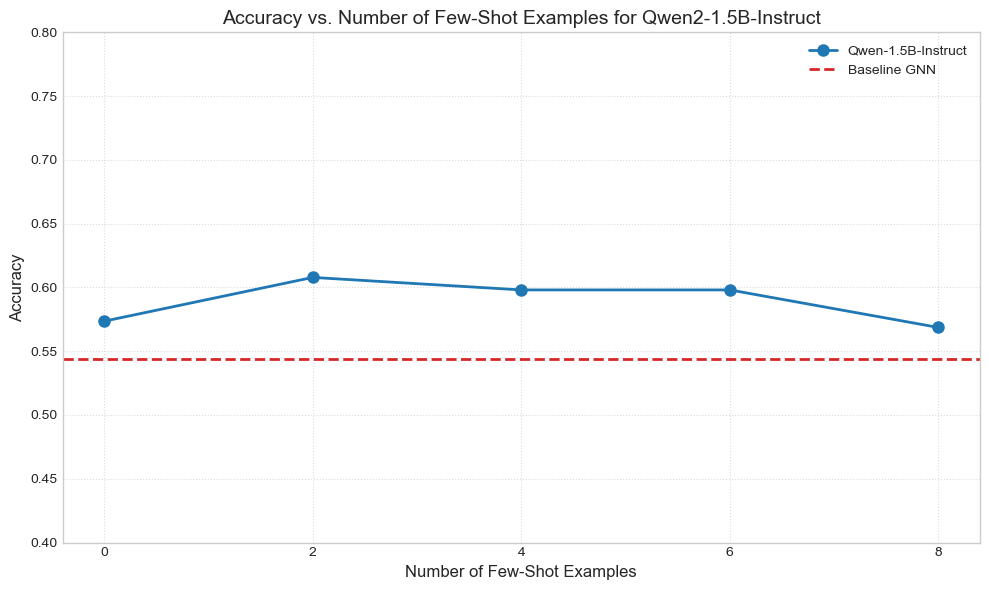

In [30]:

num_shots = [0, 2, 4, 6, 8]
qwen_small_acc = []
acc_0 = compute_metrics(qwen_small_predictions, 'True_Label', 'Predicted_Label')['accuracy']
acc_2 = compute_metrics(qwen_small_2_shots_predictions, 'True_Label', 'Predicted_Label')['accuracy']
acc_4 = compute_metrics(qwen_small_4_shots_predictions, 'True_Label', 'Predicted_Label')['accuracy']
acc_6 = compute_metrics(qwen_small_6_shots_predictions, 'True_Label', 'Predicted_Label')['accuracy']
acc_8 = compute_metrics(qwen_small_8_shots_predictions, 'True_Label', 'Predicted_Label')['accuracy']
qwen_small_acc += [acc_0, acc_2, acc_4, acc_6, acc_8]
baseline_acc= compute_metrics(baseline, 'True_Label', 'Predicted_Label')['accuracy']

plt.style.use('seaborn-v0_8-whitegrid') 

plt.figure(figsize=(10, 6)) # Slightly larger figure size
plt.plot(num_shots, qwen_small_acc, marker='o', linestyle='-', color='tab:blue', linewidth=2, markersize=8, label="Qwen-1.5B-Instruct")
plt.axhline(y=baseline_acc, linestyle='--', color='tab:red', linewidth=2, label='Baseline GNN')

plt.xlabel('Number of Few-Shot Examples', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs. Number of Few-Shot Examples for Qwen2-1.5B-Instruct', fontsize=14)
plt.xticks(num_shots, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.4, 0.8) # Ensure consistent y-axis for comparison if multiple plots
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7) # Add a subtle grid

# Improve tick formatting for percentages if desired, or just keep as is for accuracy
# plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout() 
plt.savefig('accuracy_vs_few_shot.png', dpi=300, bbox_inches='tight') 
plt.show()

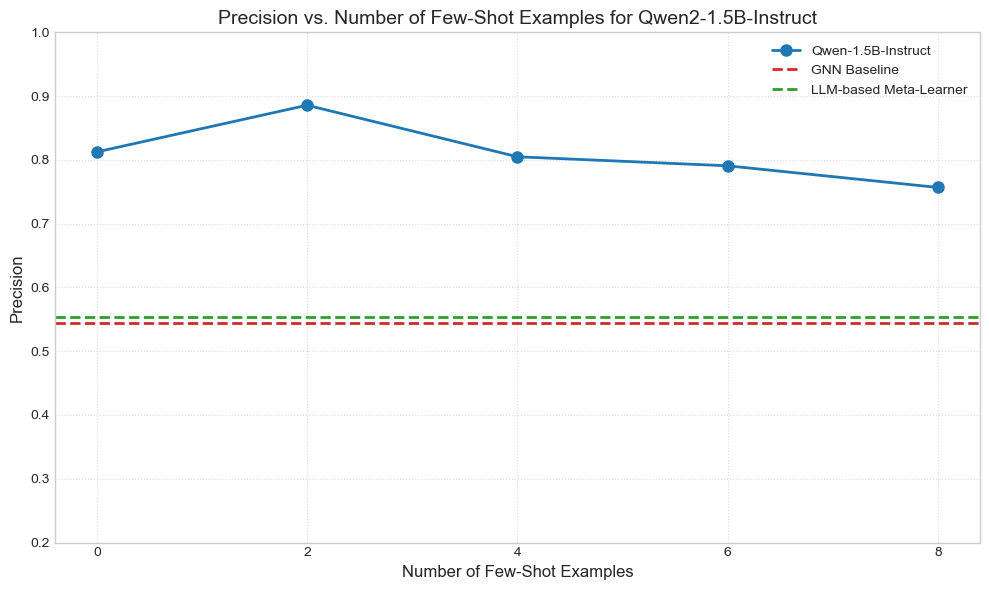

In [5]:
num_shots = [0, 2, 4, 6, 8]
qwen_small_precision = []
precision_0 = compute_metrics(qwen_small_predictions, 'True_Label', 'Predicted_Label')['precision']
qwen_small_precision.append(precision_0)
precision_2 = compute_metrics(qwen_small_2_shots_predictions, 'True_Label', 'Predicted_Label')['precision']
precision_4 = compute_metrics(qwen_small_4_shots_predictions, 'True_Label', 'Predicted_Label')['precision']
precision_6 = compute_metrics(qwen_small_6_shots_predictions, 'True_Label', 'Predicted_Label')['precision']
precision_8 = compute_metrics(qwen_small_8_shots_predictions, 'True_Label', 'Predicted_Label')['precision']
qwen_small_precision += [precision_2, precision_4, precision_6, precision_8]
baseline_precision = compute_metrics(baseline, 'True_Label', 'Predicted_Label')['precision']
llm_augmented_precision = 0.5535

plt.style.use('seaborn-v0_8-whitegrid') 

plt.figure(figsize=(10, 6)) # Slightly larger figure size
plt.plot(num_shots, qwen_small_precision, marker='o', linestyle='-', color='tab:blue', linewidth=2, markersize=8, label="Qwen-1.5B-Instruct")
plt.axhline(y=baseline_precision, linestyle='--', color='tab:red', linewidth=2, label='GNN Baseline')
plt.axhline(y=llm_augmented_precision, linestyle='--', color='tab:green', linewidth=2, label='LLM-based Meta-Learner')

plt.xlabel('Number of Few-Shot Examples', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision vs. Number of Few-Shot Examples for Qwen2-1.5B-Instruct', fontsize=14)
plt.xticks(num_shots, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.2, 1) # Ensure consistent y-axis for comparison if multiple plots
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7) # Add a subtle grid
plt.tight_layout() 
plt.savefig('precision_vs_few_shot.png', dpi=300, bbox_inches='tight') 
plt.show()